# 06 — Sentiment Analysis
**Inputs:** `data/docs_sampled.csv`, `data/hc3_BOW.csv`, `data/hc3_VOCAB.csv`

**Outputs:** `data/hc3_VOCAB_SENT.csv`, `data/hc3_BOW_SENT.csv`, `data/hc3_DOC_SENT.csv`

**Images:** `images/sentiment_plot.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
COLORS = {'human':'#4C72B0', 'chatgpt':'#DD8452'}
print('Libraries loaded.')

Libraries loaded.


In [2]:
docs_sampled = pd.read_csv('../data/docs_sampled.csv')
BOW= pd.read_csv('../data/hc3_BOW.csv')
VOCAB = pd.read_csv('../data/hc3_VOCAB.csv').set_index('term_str')
meta =docs_sampled.set_index('doc_id')[['author_type','source']]

print(f'BOW: {BOW.shape}, VOCAB: {VOCAB.shape}')

BOW: (828447, 6), VOCAB: (40531, 9)


## Load NRC Sentiment Lexicon

In [3]:
nrc_url = 'https://raw.githubusercontent.com/dinbav/LeXmo/master/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt'
nrc_response = requests.get(nrc_url)

nrc_records =[]
for line in nrc_response.text.strip().split('\n'):
    parts = line.strip().split('\t')
    if len(parts) == 3:
        nrc_records.append({'term': parts[0], 'emotion': parts[1], 'value': int(parts[2])})

nrc_df = pd.DataFrame(nrc_records)
nrc_pivot =nrc_df[nrc_df['emotion'].isin(['positive','negative'])].pivot_table(
    index='term', columns='emotion', values='value', fill_value=0
)
nrc_pivot['sentiment']= nrc_pivot.get('positive', 0) - nrc_pivot.get('negative', 0)
print(f'NRC lexicon: {len(nrc_pivot):,} terms')

NRC lexicon: 14,182 terms


## VOCAB_SENT

In [4]:
VOCAB_SENT = VOCAB.join(nrc_pivot[['sentiment']], how='inner')
VOCAB_SENT.index.name = 'term_str'
VOCAB_SENT.to_csv('../data/hc3_VOCAB_SENT.csv')
print(f'VOCAB_SENT: {len(VOCAB_SENT):,} terms with sentiment scores')
VOCAB_SENT.head()

VOCAB_SENT: 9,533 terms with sentiment scores


,n,df,p,i,dfidf,porter_stem,stop,max_pos,max_pos_group,sentiment
term_str,,,,,,,,,,
people,4570,2204,0.002843,8.458351,18642.204545,peopl,False,NNS,NOUN,0.0
make,2871,1914,0.001786,9.128991,17472.889452,make,False,VB,VERB,0.0
time,2985,1876,0.001857,9.072814,17020.598602,time,False,NN,NOUN,0.0
important,2201,1554,0.001369,9.512386,14782.247129,import,False,JJ,ADJ,1.0
good,1650,1215,0.001026,9.928079,12062.615573,good,False,JJ,ADJ,1.0


## BOW_SENT

In [5]:
sent_map = VOCAB_SENT['sentiment'].to_dict()
BOW_SENT = BOW.copy()
BOW_SENT['sentiment']= BOW_SENT['term_str'].map(sent_map)
BOW_SENT = BOW_SENT.dropna(subset=['sentiment'])
BOW_SENT['weighted_sentiment'] =BOW_SENT['n'] * BOW_SENT['sentiment']
BOW_SENT.to_csv('../data/hc3_BOW_SENT.csv', index=False)
print(f'BOW_SENT: {BOW_SENT.shape}')
BOW_SENT.head()

BOW_SENT: (243823, 8)


,doc_id,term_str,n,tf,idf,tfidf,sentiment,weighted_sentiment
8,10001_AI0,active,1,0.004149,4.781466,0.019840,0.0,0.0
9,10001_AI0,adolescence,1,0.004149,7.626375,0.031645,0.0,0.0
12,10001_AI0,age,1,0.004149,4.142063,0.017187,0.0,0.0
13,10001_AI0,alert,2,0.008299,6.100319,0.050625,0.0,0.0
19,10001_AI0,asleep,1,0.004149,5.903609,0.024496,0.0,0.0


## DOC_SENT

In [6]:
DOC_SENT = (
    BOW_SENT.groupby('doc_id')
    .agg(total_sentiment=('weighted_sentiment','sum'),
         total_tokens=('n','sum'))
)
DOC_SENT['mean_sentiment'] = DOC_SENT['total_sentiment'] /DOC_SENT['total_tokens']
DOC_SENT= DOC_SENT.join(meta)
DOC_SENT.index.name = 'doc_id'
DOC_SENT.to_csv('../data/hc3_DOC_SENT.csv')

print(f'DOC_SENT: {DOC_SENT.shape}')
print('\nMean sentiment by author type:')
print(DOC_SENT.groupby('author_type')['mean_sentiment'].mean().round(4).to_string())

DOC_SENT: (10219, 5)

Mean sentiment by author type:
author_type
chatgpt    0.1160
human      0.0645


## Sentiment Plot

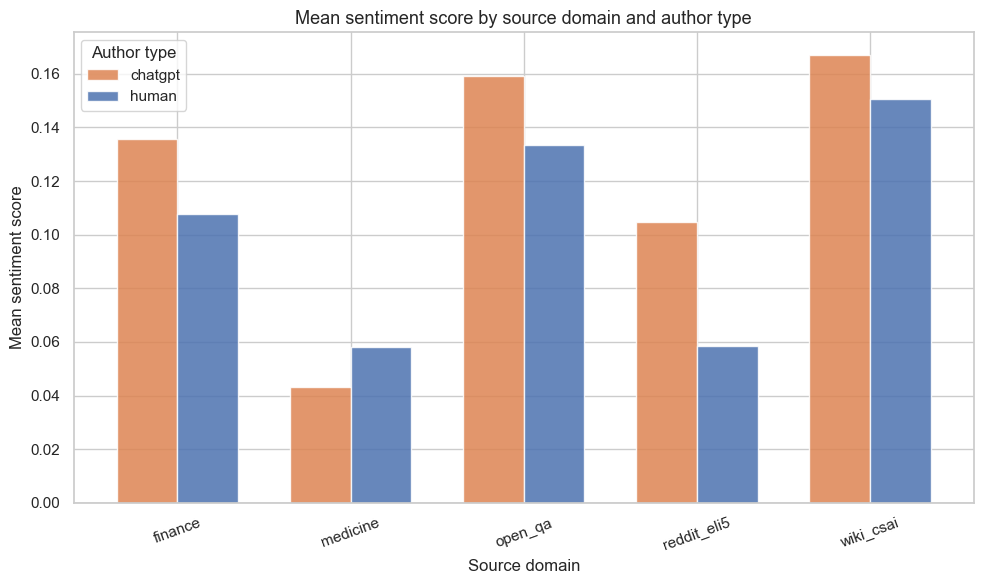

Saved images/sentiment_plot.png


In [7]:
sent_source= DOC_SENT.groupby(['source','author_type'])['mean_sentiment'].mean().unstack()

fig, ax =plt.subplots(figsize=(10, 6))
sent_source.plot(kind='bar', ax=ax, color=[COLORS['chatgpt'], COLORS['human']], alpha=0.85, width=0.7)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Mean sentiment score by source domain and author type', fontsize=13)
ax.set_xlabel('Source domain', fontsize=12)
ax.set_ylabel('Mean sentiment score', fontsize=12)
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Author type', fontsize=11)
plt.tight_layout()
plt.savefig('../images/sentiment_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved images/sentiment_plot.png')